In [1]:
import os
import numpy as np
import pandas as pd

### import age_matrtix,diabetes,hypertension, albu_matirx


In [2]:
from Age_BMI_loading import age_matrix_vec,bmi_matrix_ls,age_dict

In [3]:
from prevalence import get_prevalence,get_pre_prevalence,get_overall_prevalence,get_overall_pre_prevalence

In [13]:
# Load the saved matrices and check their sizes
albu_mat_storage = []
for i in range(8):
    filename = f'../data/albu_matrix/albu_1_mat_group_{i}.npy'
    loaded_array = np.load(filename)
    albu_mat_storage.append(loaded_array)
    print(f"Loaded group {i} array from {filename}, shape: {loaded_array.shape}")

Loaded group 0 array from ../data/albu_matrix/albu_1_mat_group_0.npy, shape: (2, 88417, 34)
Loaded group 1 array from ../data/albu_matrix/albu_1_mat_group_1.npy, shape: (2, 91217, 34)
Loaded group 2 array from ../data/albu_matrix/albu_1_mat_group_2.npy, shape: (2, 16696, 34)
Loaded group 3 array from ../data/albu_matrix/albu_1_mat_group_3.npy, shape: (2, 16310, 34)
Loaded group 4 array from ../data/albu_matrix/albu_1_mat_group_4.npy, shape: (2, 12057, 34)
Loaded group 5 array from ../data/albu_matrix/albu_1_mat_group_5.npy, shape: (2, 10812, 34)
Loaded group 6 array from ../data/albu_matrix/albu_1_mat_group_6.npy, shape: (2, 3903, 34)
Loaded group 7 array from ../data/albu_matrix/albu_1_mat_group_7.npy, shape: (2, 4679, 34)


In [5]:


# Create albu_mat_list by extracting mat[0,:,:] from all loaded matrices
albu_mat_list = []
for matrix in loaded_albu_1_mat_storage:
    # Extract the first 2D slice (mat[0,:,:]) and append to list
    matrix_2d = matrix[0, :, :]
    albu_mat_list.append(matrix_2d)
overall_prevalence = get_overall_prevalence(age_matrix_vec,albu_mat_list,-2)

In [6]:
overall_prevalence
# correct answer: 0.0086

0.015592082776621198

In [7]:
# ## Load diabetes matrices

# Load the saved diabetes matrices
diabetes_mat_list = []
save_dir = "../data/diabetes_matrix"
for i in range(8):  # Assuming 10 matrices, adjust as needed
    filename = os.path.join(save_dir, f"diabetes_mat_{i}.npy")
    if os.path.exists(filename):
        diabetes_mat = np.load(filename)
        diabetes_mat_list.append(diabetes_mat)
        print(f"Loaded diabetes matrix {i} from {filename}, shape: {diabetes_mat.shape}")
    

Loaded diabetes matrix 0 from ../data/diabetes_matrix/diabetes_mat_0.npy, shape: (88417, 34)
Loaded diabetes matrix 1 from ../data/diabetes_matrix/diabetes_mat_1.npy, shape: (91217, 34)
Loaded diabetes matrix 2 from ../data/diabetes_matrix/diabetes_mat_2.npy, shape: (16696, 34)
Loaded diabetes matrix 3 from ../data/diabetes_matrix/diabetes_mat_3.npy, shape: (16310, 34)
Loaded diabetes matrix 4 from ../data/diabetes_matrix/diabetes_mat_4.npy, shape: (12057, 34)
Loaded diabetes matrix 5 from ../data/diabetes_matrix/diabetes_mat_5.npy, shape: (10812, 34)
Loaded diabetes matrix 6 from ../data/diabetes_matrix/diabetes_mat_6.npy, shape: (3903, 34)
Loaded diabetes matrix 7 from ../data/diabetes_matrix/diabetes_mat_7.npy, shape: (4679, 34)


In [8]:
overall_prevalence = get_overall_prevalence(age_matrix_vec,diabetes_mat_list,-2)

In [9]:
overall_prevalence * 100

8.726967653730231

In [10]:
# Load hypertension matrices
import os

# Load the saved hypertension matrices
hyper_mat_list = []
save_dir = "../data/hyper_matrix"
for i in range(8):  # Assuming 8 matrices for 8 ethnicity-gender groups
    filename = os.path.join(save_dir, f"hyper_mat_{i}.npy")
    if os.path.exists(filename):
        hyper_mat = np.load(filename)
        hyper_mat_list.append(hyper_mat)
        print(f"Loaded hypertension matrix {i} from {filename}, shape: {hyper_mat.shape}")


Loaded hypertension matrix 0 from ../data/hyper_matrix/hyper_mat_0.npy, shape: (88417, 34)
Loaded hypertension matrix 1 from ../data/hyper_matrix/hyper_mat_1.npy, shape: (91217, 34)
Loaded hypertension matrix 2 from ../data/hyper_matrix/hyper_mat_2.npy, shape: (16696, 34)
Loaded hypertension matrix 3 from ../data/hyper_matrix/hyper_mat_3.npy, shape: (16310, 34)
Loaded hypertension matrix 4 from ../data/hyper_matrix/hyper_mat_4.npy, shape: (12057, 34)
Loaded hypertension matrix 5 from ../data/hyper_matrix/hyper_mat_5.npy, shape: (10812, 34)
Loaded hypertension matrix 6 from ../data/hyper_matrix/hyper_mat_6.npy, shape: (3903, 34)
Loaded hypertension matrix 7 from ../data/hyper_matrix/hyper_mat_7.npy, shape: (4679, 34)


In [11]:
overall_prevalence = get_overall_prevalence(age_matrix_vec,hyper_mat_list,-2)
overall_prevalence

0.3665537706242426

## deal with CKD 

In [14]:

import numpy as np

coefficients = {
    'chn mal': np.array([130.84 , -0.4671, 14.9112, 0, -5.3749 , 13.3742], dtype=object),
    'chn fem':np.array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
    'ind mal': np.array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object),
    'ind fem': np.array([118.31, -0.3034, 19.8534, 0, -4.6831 , 14.4905], dtype=object),
    'mal mal': np.array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object),
    'mal fem': np.array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)
}

print(coefficients)


## use negative
def map_eth_str(idx):
    ethnic_keys = ['chn mal','chn fem','mal mal','mal fem','ind mal','ind fem','mal mal','mal fem']  # Mapping indices to dictionary keys
    return ethnic_keys[idx ]

import numpy as np

eGFR_matrix_ls = []  # List to store eGFR matrices

for idx in range(8):
  # Iterate over the two cases
    case_matrices = []  # Store matrices for this case
    for i, k in enumerate([0, 1]):
        # Extract age matrix for this index
        matrix = age_matrix_vec[idx]  # Contains age values
        bmi_values = bmi_matrix_ls[idx]  # Corresponding BMI values
        albu_value = albu_mat_storage[idx][k, :, :]
        diabete_value = diabetes_mat_list[idx]
        hyper_value = hyper_mat_list[idx]
        
        eGFR_matrix = np.zeros_like(matrix, dtype=float)
        
        # Get ethnicity and gender
        eth = map_eth_str(idx)  # 'chn', 'ind', or 'mal'
        gender2 = idx % 2  # 0 for Male, 1 for Female

        # Extract coefficients for the ethnicity
        beta0, beta1, beta2, beta3, beta4, sigma = coefficients[eth]
        
        # Generate noise
        row_noise = np.random.normal(loc=0, scale=sigma, size=matrix.shape)
        
        # Compute coefficients based on conditions
        diabetes_coefficient = np.where(diabete_value == 0.5, 0.5, np.where(diabete_value == 1, 1., 0))
        albu_coefficient = np.where(albu_value == 1, 0.1, np.where(albu_value == 2, 0.5, 0))
        hyper_coefficient = 0.1

        # Compute eGFR values
        eGFR_matrix = (
            beta0 +
            beta1 * matrix * 0.5 +  # Age contribution
            beta2 * gender2 +  # Gender contribution
            beta3 * matrix * gender2 * 0.5 +  # Age * Gender interaction
            beta4 * np.log(bmi_values) +  # BMI contribution
            beta1 * matrix * hyper_coefficient * hyper_value + 
            beta1 * matrix * diabetes_coefficient * diabete_value + 
            beta1 * matrix * albu_coefficient * albu_value + 
            row_noise  # Random noise
        )
        
        # Replace invalid age values with -1 in eGFR matrix
        eGFR_matrix[matrix == -1] = -1
        
        case_matrices.append(eGFR_matrix)
    case_matrices = np.array(case_matrices)
    
    eGFR_matrix_ls.append(case_matrices)

# Convert list to a NumPy array for better structure


# Display the resulting eGFR matrix
print("eGFR Matrix:")
print(eGFR_matrix_ls[0][0,:,:])


{'chn mal': array([130.84, -0.4671, 14.9112, 0, -5.3749, 13.3742], dtype=object), 'chn fem': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'ind mal': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'ind fem': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'mal mal': array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object), 'mal fem': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_51552/2855490156.py:58: RuntimeWarning: invalid value encountered in log
  beta4 * np.log(bmi_values) +  # BMI contribution


eGFR Matrix:
[[102.30493129 131.04073674 124.97688704 ... 123.37278678 103.66747198
  115.95919744]
 [125.05942436 132.28719501 125.73225661 ... 120.22623144 103.56222038
   90.03327747]
 [111.16712005 103.42517779 146.55605119 ...  93.85880085 124.90617765
   85.99479932]
 ...
 [ -1.          -1.          -1.         ...  -1.          -1.
   87.23740773]
 [ -1.          -1.          -1.         ...  -1.          -1.
  123.16807555]
 [ -1.          -1.          -1.         ...  -1.          -1.
   95.43976019]]


In [15]:
stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}

# For each matrix, create a corresponding stage matrix (same shape) where each element gets the stage value.
stage_matrix_ls = []
for i in range(8):
    matrix = eGFR_matrix_ls[i][-1]
    # Initialize an output matrix with NaNs
    stage_matrix = np.full(matrix.shape, np.nan)
    # For every stage, update the positions where the condition is True
    for stage, condition in stages.items():
        mask = condition(matrix)
        stage_matrix[mask] = stage
    stage_matrix_ls.append(stage_matrix)


In [17]:
age_matrix_vec[0].shape

(88417, 34)

In [22]:

# Initialize total counts


# Initialize lists to store prevalence for each scenario
prevalence_k0 = []
prevalence_k1 = []

# Iterate through each year (columns -34 to -2)
for year_col in range(-34, -1):
    # For k=0 and k=1 scenarios
    for k in [0, -1]:
        total_population = 0
        total_ckd_cases = 0

        # Iterate over 8 ethnicity groups
        for i in range(8):
            # Extract age, diabetes, ACR, and stage matrices
            ages = age_matrix_vec[i][:, year_col]
            acr_values = albu_mat_storage[i][k, :, year_col]  # ACR for scenario k
            stages_col = stage_matrix_ls[i][:, year_col]

            # Apply age mask
            age_mask = (ages >= 18) & (ages <= 74)

            # Filter variables based on the mask
            filtered_stages = stages_col[age_mask]
            filtered_acr = acr_values[age_mask]

            # Define healthy condition: stage 0 or 1 and ACR = 0
            healthy_mask = (filtered_stages <=2) & (filtered_acr == 0)

            # Identify non-healthy (CKD) cases
            non_healthy_mask = ~healthy_mask

            # Count total people and CKD cases in this ethnicity group
            total_population += np.sum(age_mask)
            total_ckd_cases += np.sum(non_healthy_mask)

        # Compute overall prevalence
        overall_ckd_prevalence = (total_ckd_cases / total_population) * 100
        
        # Store in appropriate list based on k value
        if k == 0:
            prevalence_k0.append(overall_ckd_prevalence)
        else:
            prevalence_k1.append(overall_ckd_prevalence)

# Create dataframe with both scenarios
prevalence_df = pd.DataFrame({
    'k0_prevalence': prevalence_k0,
    'k1_prevalence': prevalence_k1
})

# Print result
print(f"Overall CKD Prevalence (Ages 18-74): {total_ckd_cases} / {total_population} ({overall_ckd_prevalence:.2f}%)")

Overall CKD Prevalence (Ages 18-74): 35010 / 160915 (21.76%)


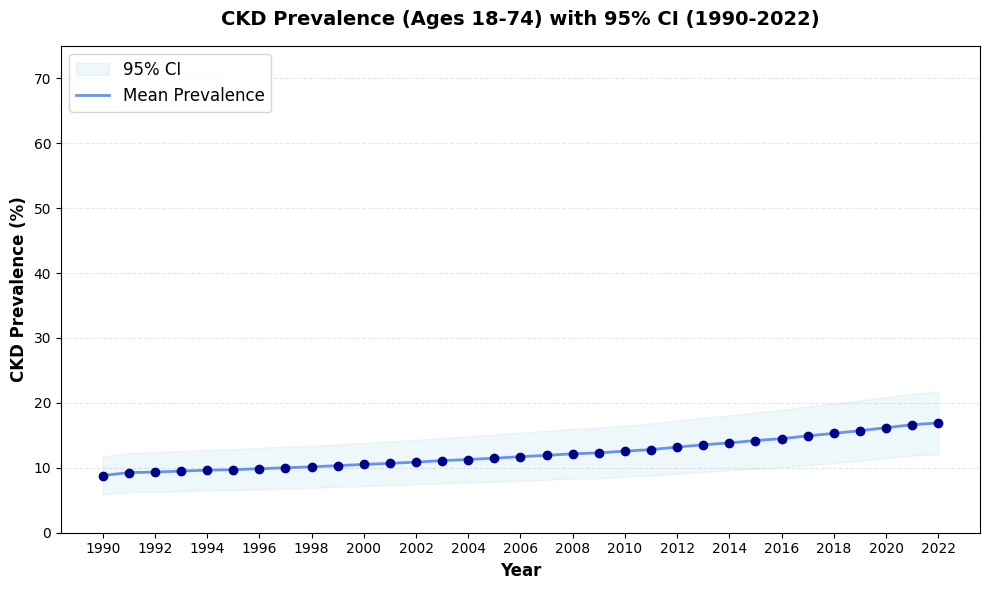

In [23]:
import matplotlib.pyplot as plt
# Set initial and final years
start_year = 1990  # Can be changed to 2000 or other year
end_year = 2022

# Create years array
years = np.arange(start_year, end_year + 1)
num_years = len(years)

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot the confidence interval as a shaded region
plt.fill_between(years, prevalence_df['k0_prevalence'][-num_years:], 
                 prevalence_df['k1_prevalence'][-num_years:], 
                 alpha=0.2, color='lightblue', label='95% CI')

# Plot the mean line
mean_prevalence = (prevalence_df['k0_prevalence'][-num_years:] + 
                  prevalence_df['k1_prevalence'][-num_years:])/2
plt.plot(years, mean_prevalence, color='#6495ED', linewidth=2, label='Mean Prevalence')

# Add dots for mean prevalence values
plt.plot(years, mean_prevalence, 'o', color='darkblue', markersize=6)

# Add specific data points
# plt.plot([2019], [8.7], 'o', color='red', markersize=8, label='2020 Data Point')
# plt.plot([2022], [13.8], 'o', color='red', markersize=8, label='2022 Data Point')

# Customize the plot
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontsize=12, fontweight='bold')
plt.title(f'CKD Prevalence (Ages 18-74) with 95% CI ({start_year}-{end_year})',
         fontsize=14, fontweight='bold', pad=15)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Customize ticks
plt.xticks(years[::2])  # Show every 2nd year
plt.tick_params(axis='both', labelsize=10)
plt.ylim(0,75)
# Add legend
plt.legend(loc='upper left', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

